In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline


In [2]:
df=pd.read_csv('economic_index.csv')

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [7]:
#as here we have two independent features interest_rate and unemployement_rate and index_price as dependent feature.
#other are unnecessary features like unnamed:0 and year, month that doesnt effect the price. we remove it
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [8]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
df.corr()#interest_rate and indexprice are positively correlated. interestrate and unemp are negatively correlated.unemp and indexprice are negatively correlated.


,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


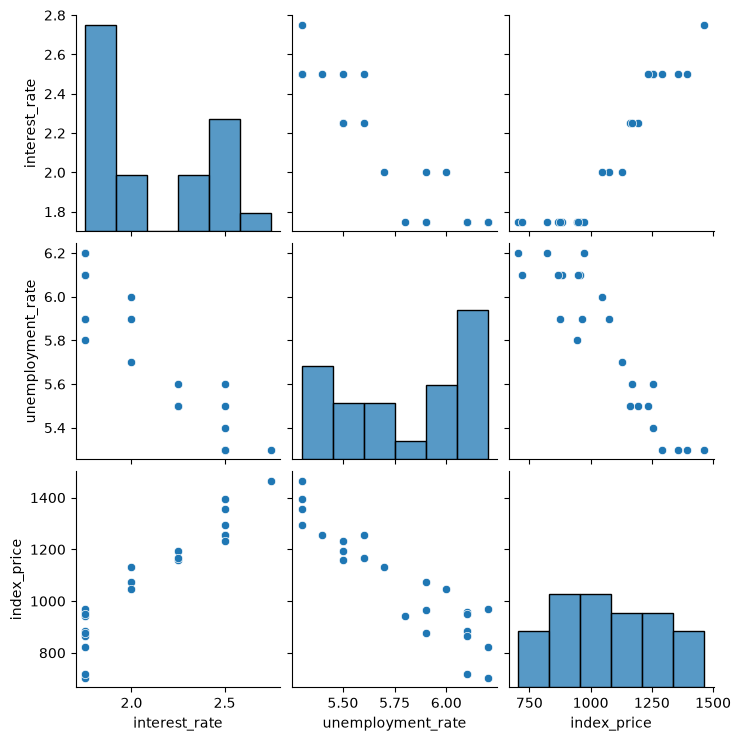

In [11]:
import seaborn as sns
sns.pairplot(df)

Text(0, 0.5, 'unemployement_rate')

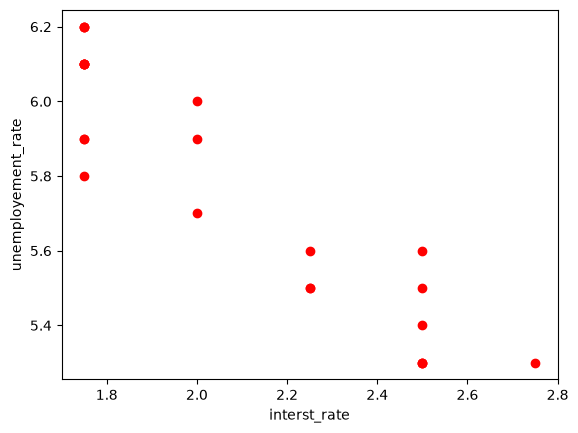

In [14]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel('interst_rate')
plt.ylabel('unemployement_rate')

<Axes: xlabel='interest_rate', ylabel='index_price'>

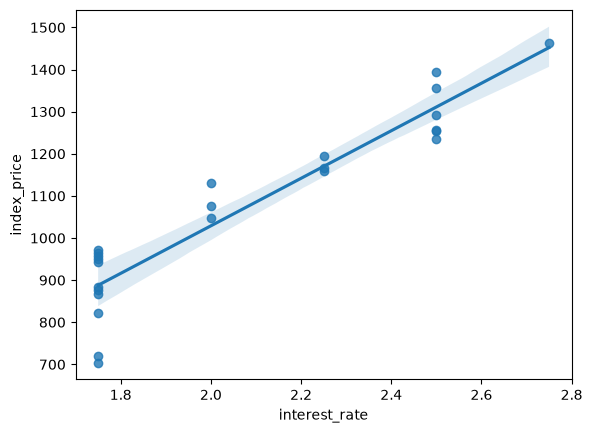

In [26]:
sns.regplot(x=df['interest_rate'],y=df['index_price'])

In [17]:
#divide dataset in independent and dependent features
x=df[['interest_rate','unemployment_rate']]
y=df['index_price']


In [18]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [19]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [27]:
#values standardization zscore
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [28]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [ ]:
regression.fit(xtrain,ytrain)#trained

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#for hyperparameter we can further divide our training data into test and validation. called cross validation
from sklearn.model_selection import cross_val_score
validation=cross_val_score(regression,xtrain,ytrain,scoring='neg_mean_squared_error',cv=3) #estimator=model cv= no of mse values


In [31]:
validation

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [32]:
np.mean(validation)

np.float64(-5914.828180162386)

In [33]:
ypred=regression.predict(xtest)
ypred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [35]:
#performance matrices
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(ytest,ypred)
mae=mean_absolute_error(ytest,ypred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [ ]:
#evaluation of model performance
from sklearn.metrics import r2_score
score=r2_score(ytest,ypred)
print(score)
print(#adjusted r^2
#display adjusted R-squared
1 - (1-score)*(len(ytest)-1)/(len(ytest)-xtest.shape[1]-1)
)

0.8278978091457145
0.7131630152428576


### Assumptions

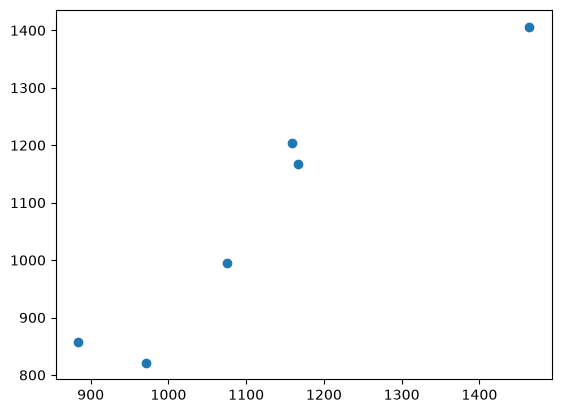

In [ ]:
plt.scatter(ytest,ypred)#having linear relation which shows that the model is working fine 

In [40]:
residuals=ytest-ypred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

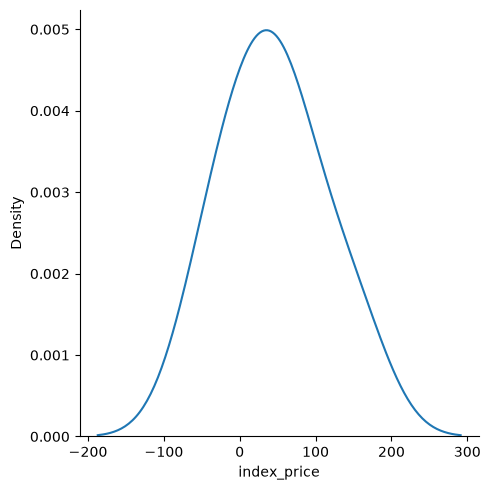

In [ ]:
sns.displot(residuals,kind='kde')#if normal distribution in displot means the model we created is good

In [42]:
import statsmodels.api as sm
model=sm.OLS(ytrain,xtrain).fit()


In [43]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 15 Jul 2026   Prob (F-statistic):                       0.754
Time:                        01:23:46   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [44]:
print(regression.coef_)

[  88.27275507 -116.25716066]
